In [5]:
import tensorflow as tf
from src.history import load_history
from src.dataset import load_dataset, preprocess
from src.losses import CombinedDiceCCELoss, DiceLoss
from src.eval import compare_segmentation_models
from src.history import load_history
import matplotlib.pyplot as plt

In [2]:
_, val_ds, test_ds, _ = load_dataset()
#val_ds = preprocess(val_ds, augmentation = False, training = False)
test_ds = preprocess(test_ds, augmentation = False, training = False)

In [3]:
base_cce_model = tf.keras.models.load_model('models/base_unet.keras')
dice_loss_model = tf.keras.models.load_model('models/dice_unet.keras', custom_objects={'DiceLoss': DiceLoss})
combined_model = tf.keras.models.load_model(
    'models/dice_cce_unet.keras', 
    custom_objects={'CombinedDiceCCELoss': CombinedDiceCCELoss}
)

Images will be saved to local folder: 'images/trandom_10_preds.png'
Showing 10 random samples...
Saved: images/trandom_10_preds.png\model_comparison_sample_random_0.png


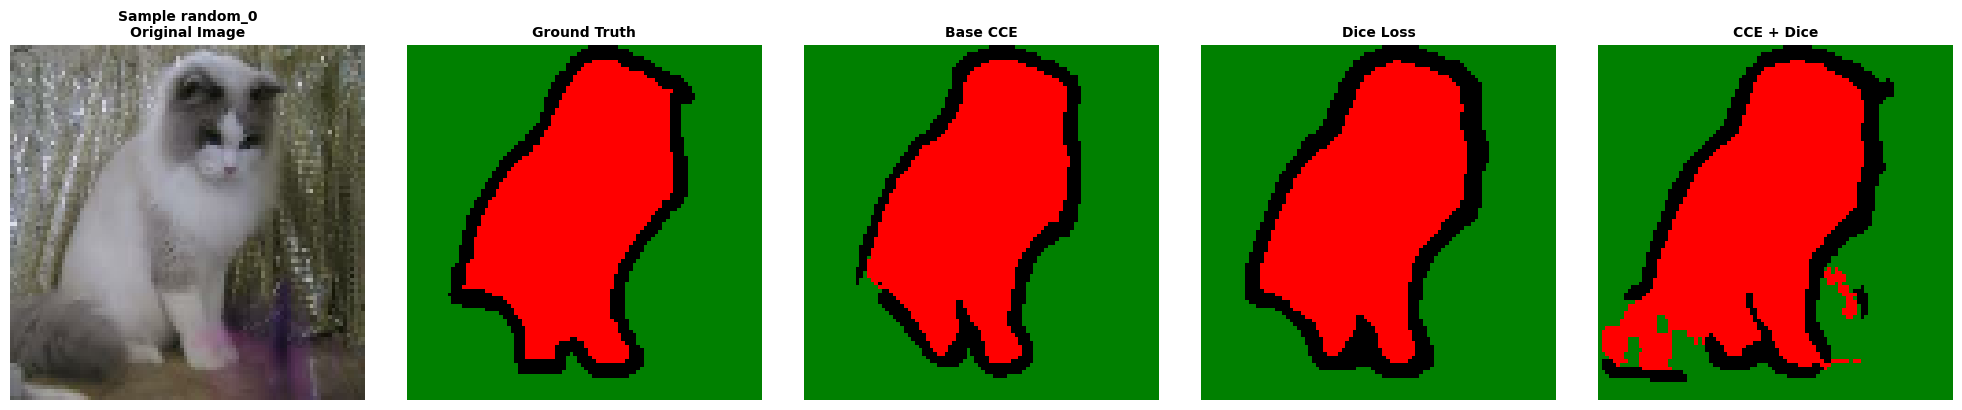

Saved: images/trandom_10_preds.png\model_comparison_sample_random_1.png


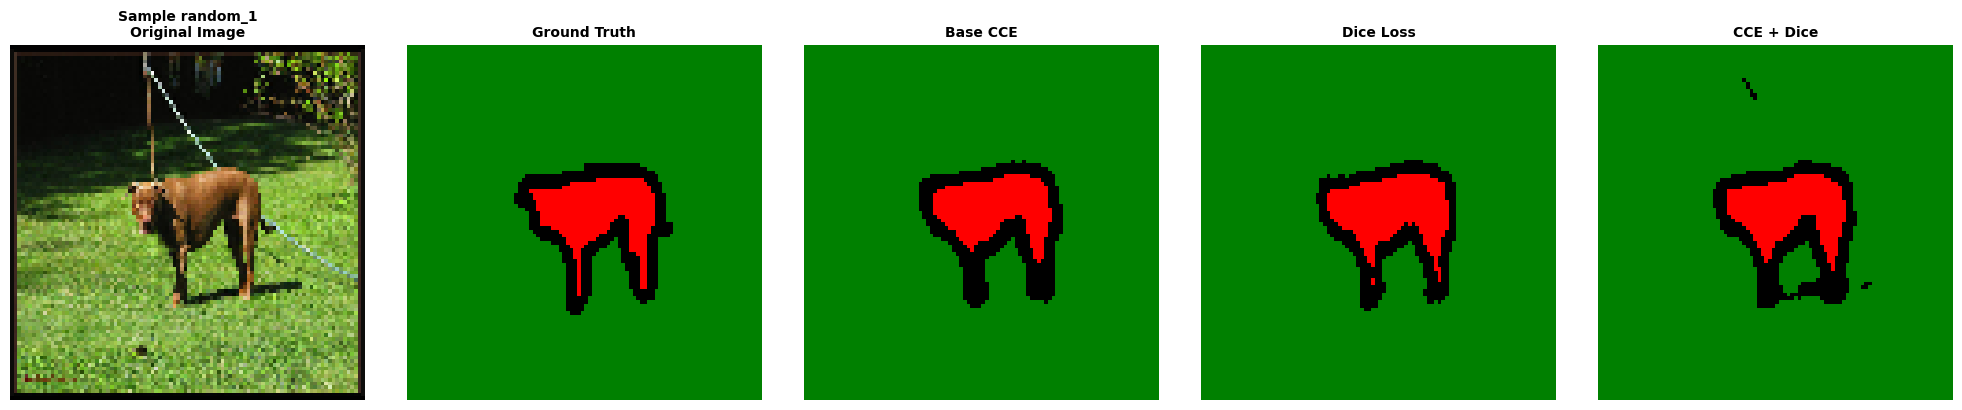

Saved: images/trandom_10_preds.png\model_comparison_sample_random_2.png


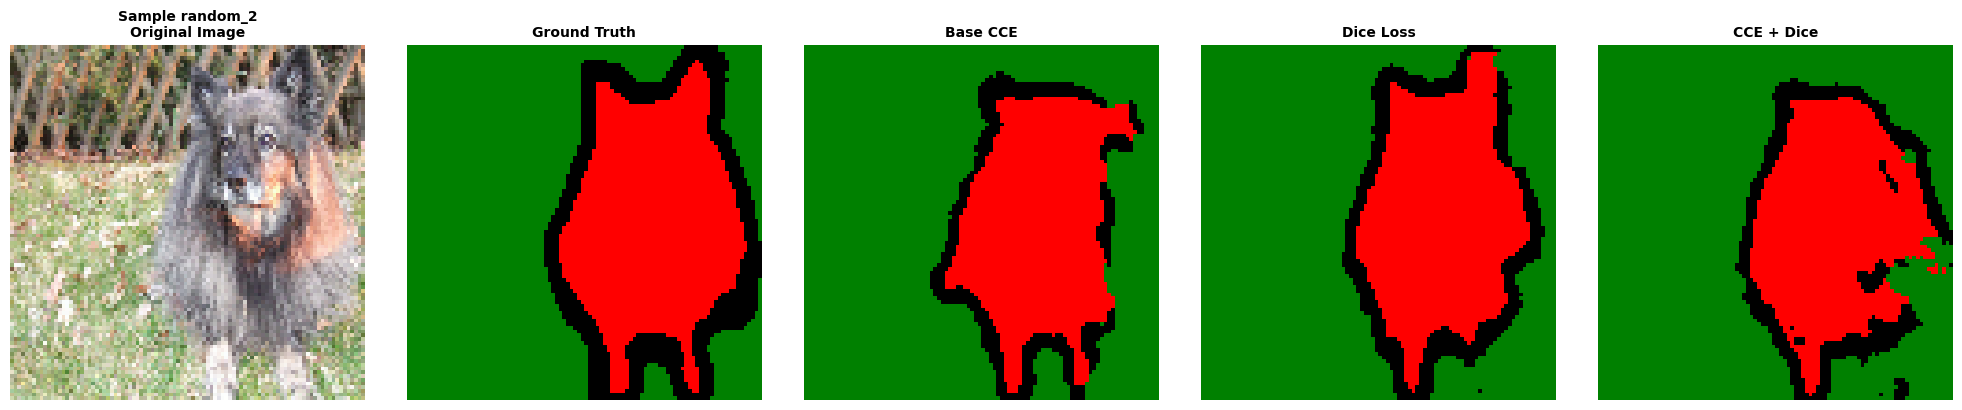

Saved: images/trandom_10_preds.png\model_comparison_sample_random_3.png


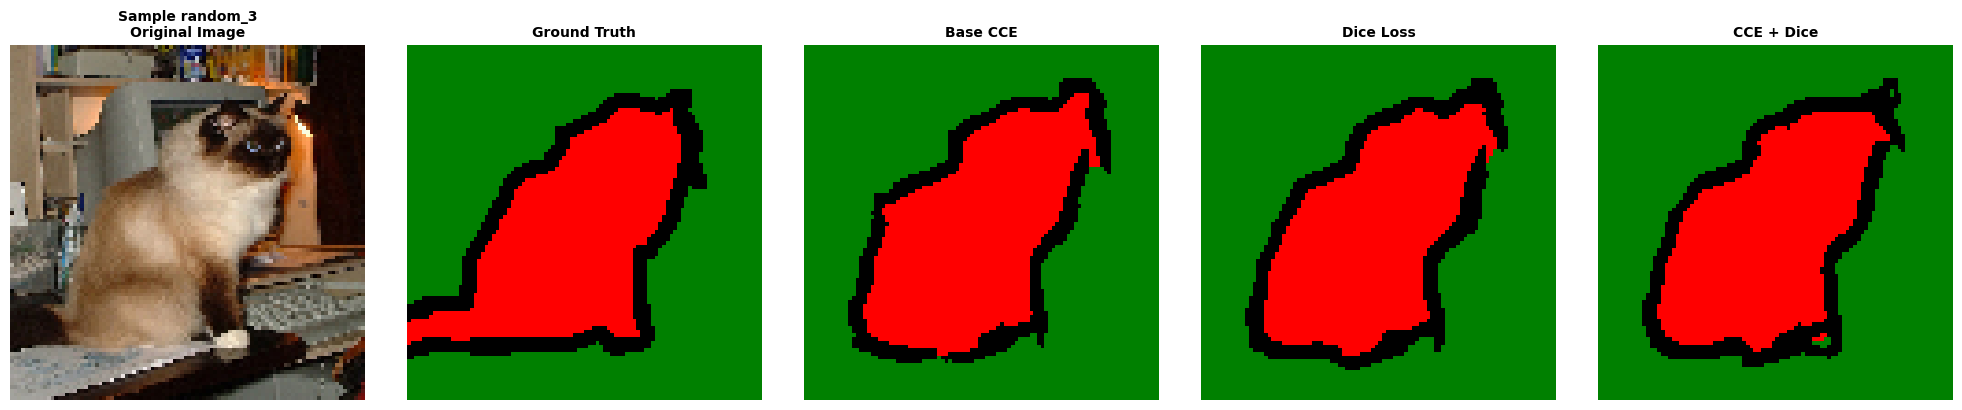

Saved: images/trandom_10_preds.png\model_comparison_sample_random_4.png


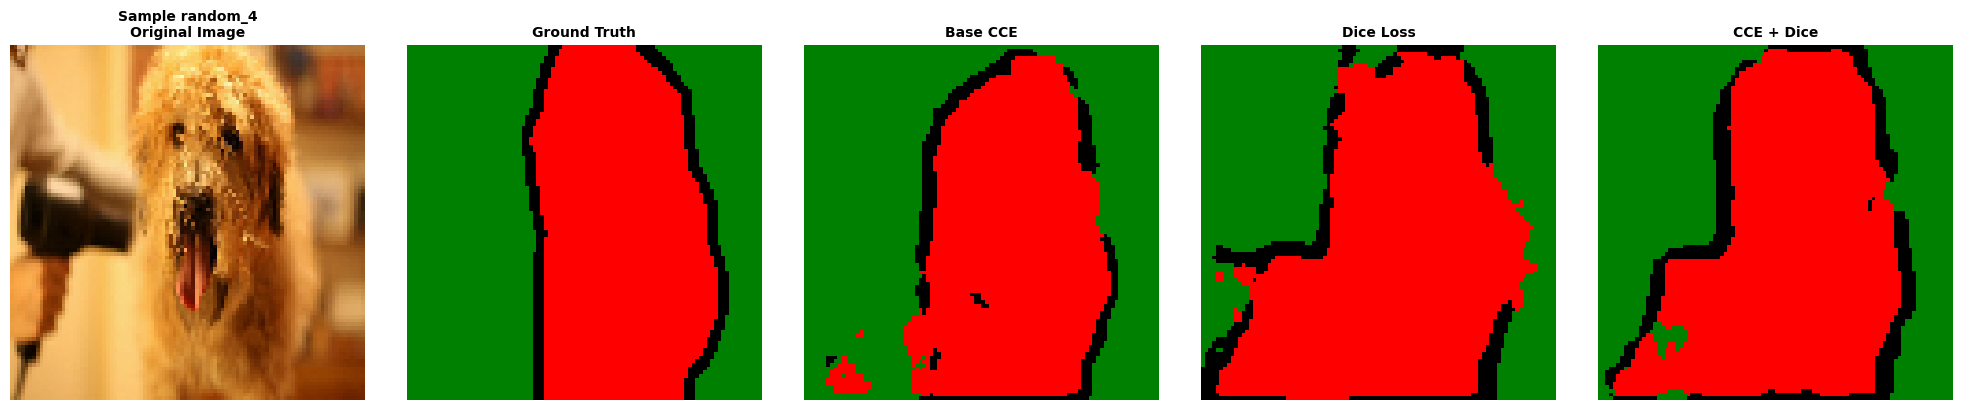

Saved: images/trandom_10_preds.png\model_comparison_sample_random_5.png


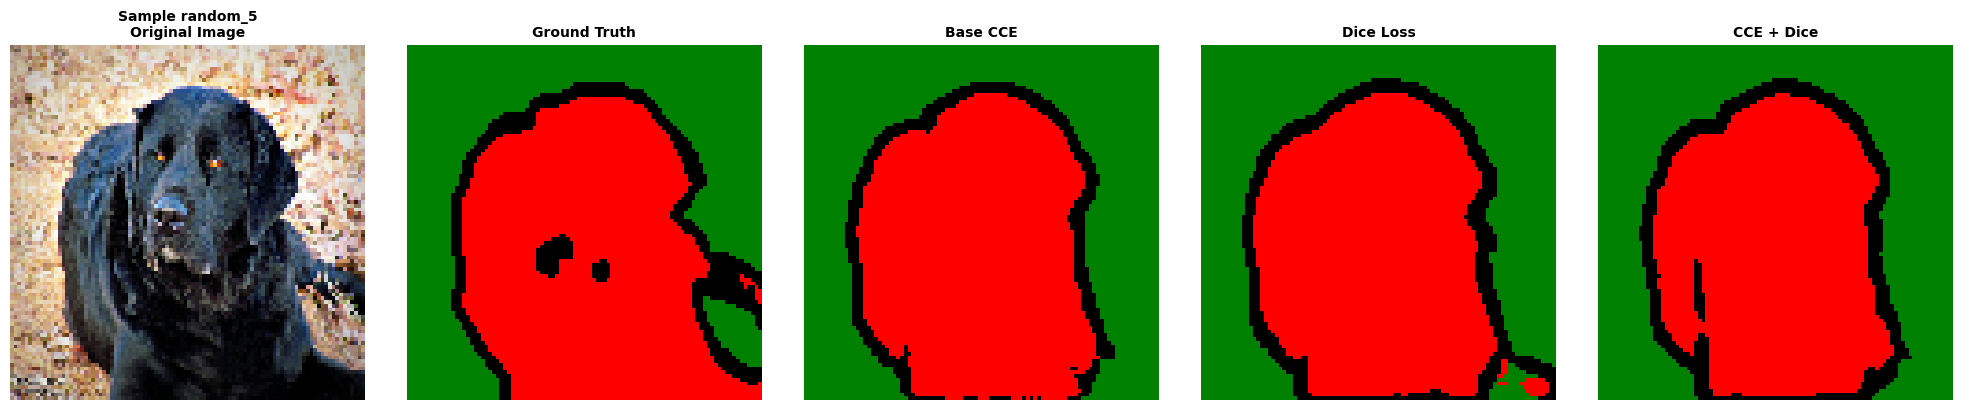

Saved: images/trandom_10_preds.png\model_comparison_sample_random_6.png


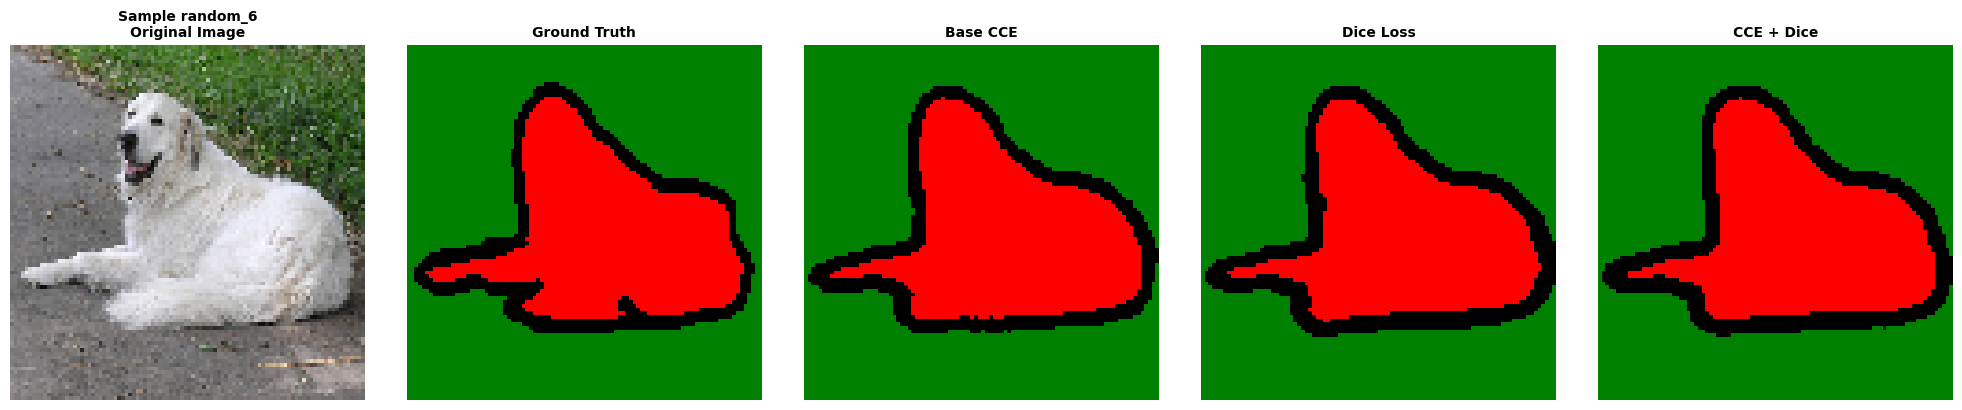

Saved: images/trandom_10_preds.png\model_comparison_sample_random_7.png


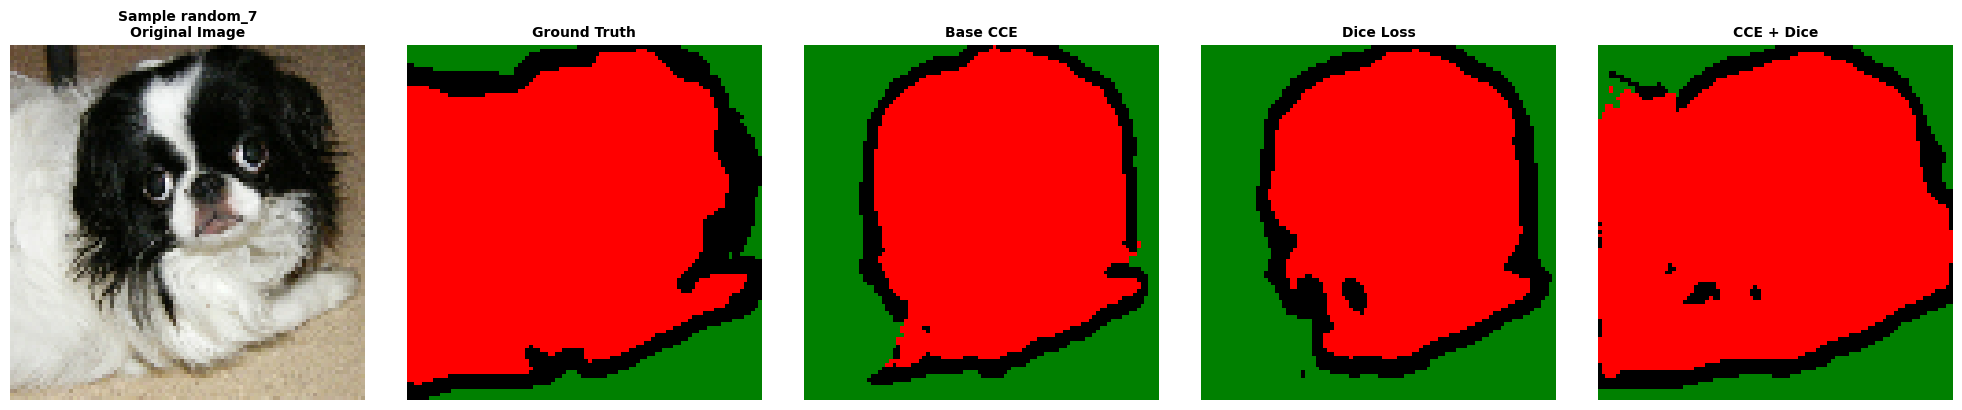

Saved: images/trandom_10_preds.png\model_comparison_sample_random_8.png


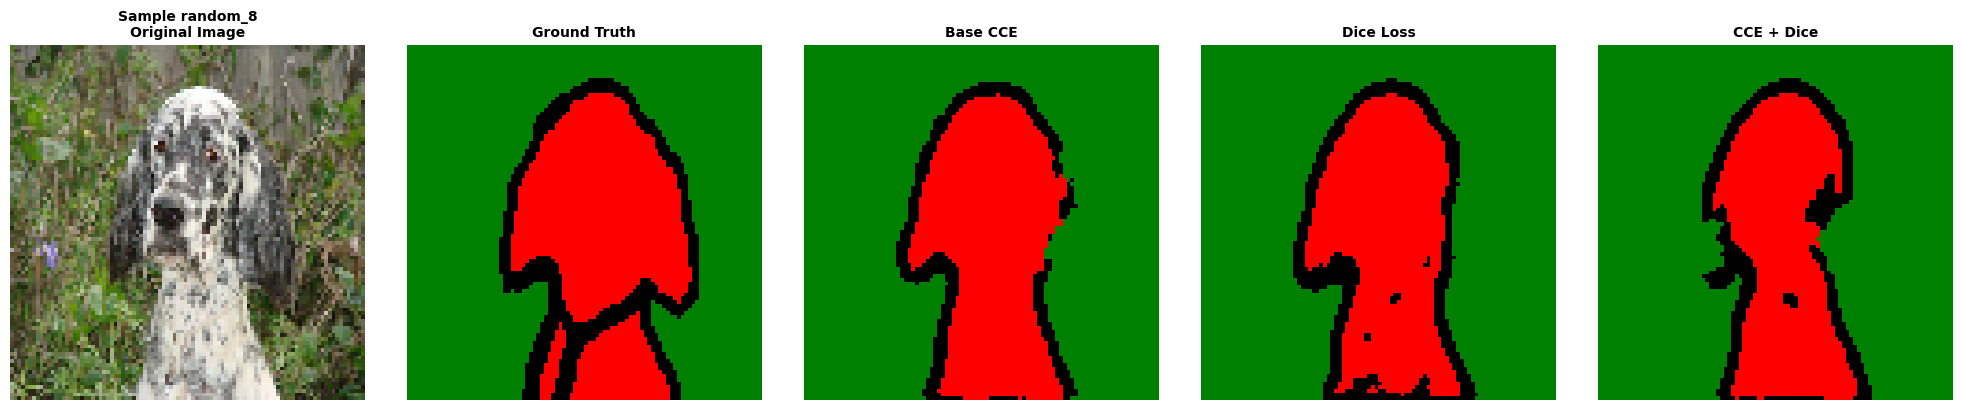

Saved: images/trandom_10_preds.png\model_comparison_sample_random_9.png


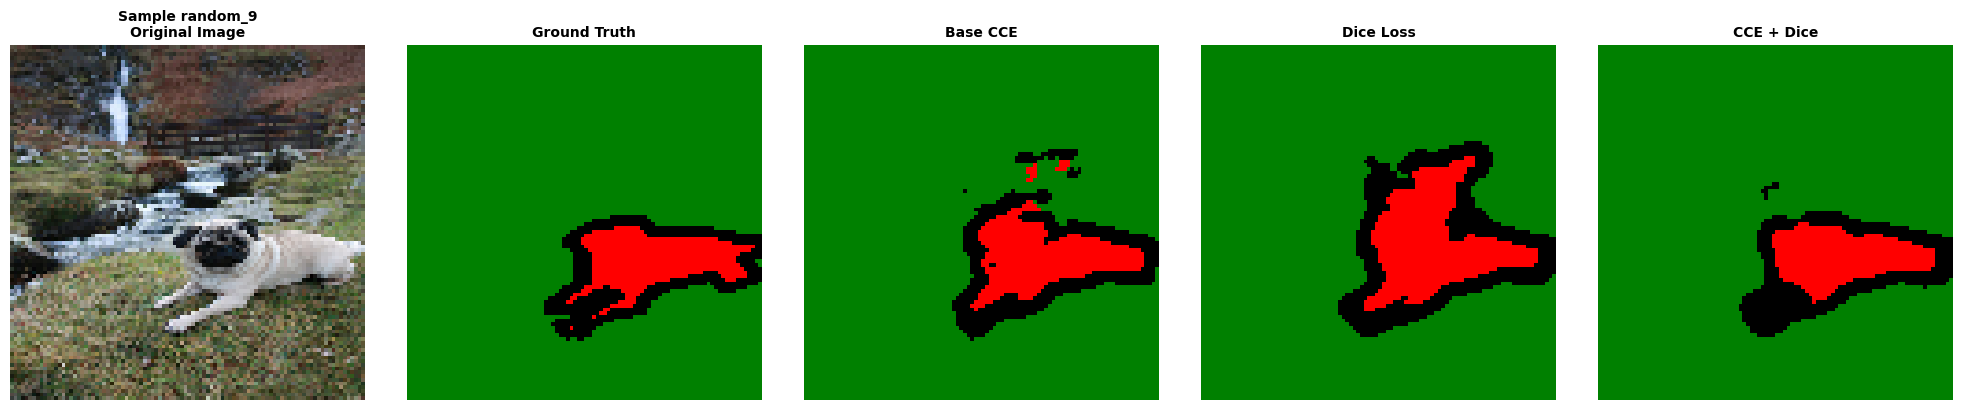

In [4]:
# 1. Define your dictionary of models
my_models = {
    "Base CCE": base_cce_model,
    "Dice Loss": dice_loss_model,
    "CCE + Dice": combined_model
}

# 2. Call the function using your existing test dataset pipeline
compare_segmentation_models(
    models_dict=my_models,
    dataset=test_ds,
    num_samples=10,
    shuffle=True,
    save_dir="images/trandom_10_preds.png"
)

In [17]:
base_cce_model.evaluate(test_ds)

115/115 ━━━━━━━━━━━━━━━━━━━━ 30s 246ms/step - accuracy: 0.8903 - loss: 0.2964 - mean_iou: 0.7159


[0.29641348123550415, 0.890312135219574, 0.7158542275428772]

In [18]:
dice_loss_model.evaluate(test_ds)

115/115 ━━━━━━━━━━━━━━━━━━━━ 30s 244ms/step - accuracy: 0.8983 - loss: 0.1729 - mean_iou: 0.7389


[0.17294658720493317, 0.898280143737793, 0.738915205001831]

In [19]:
combined_model.evaluate(test_ds)

115/115 ━━━━━━━━━━━━━━━━━━━━ 33s 269ms/step - accuracy: 0.8947 - loss: 0.4942 - mean_iou: 0.7304


[0.49418261647224426, 0.8946946859359741, 0.7303943634033203]

In [6]:
history_base = history_no_aug= load_history("history/base_history.pkl")
history_dice = history_no_aug= load_history("history/dice_history1.pkl")
history_combined = history_no_aug= load_history("history/dice_cce_history.pkl")

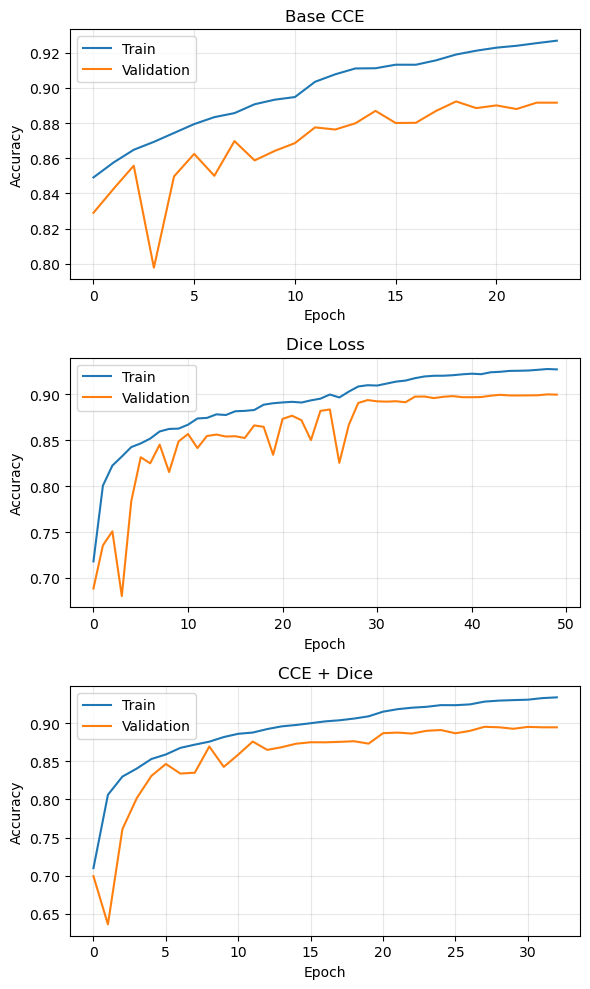

In [27]:
histories = [
    ("Base CCE", history_base),
    ("Dice Loss", history_dice),
    ("CCE + Dice", history_combined)
]

fig, axes = plt.subplots(3,1, figsize=(6,10))
for ax, (title, history) in zip(axes.flat, histories):
    ax.plot(history["accuracy"], label="Train")
    ax.plot(history["val_accuracy"], label="Validation")

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(
    "images/training_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

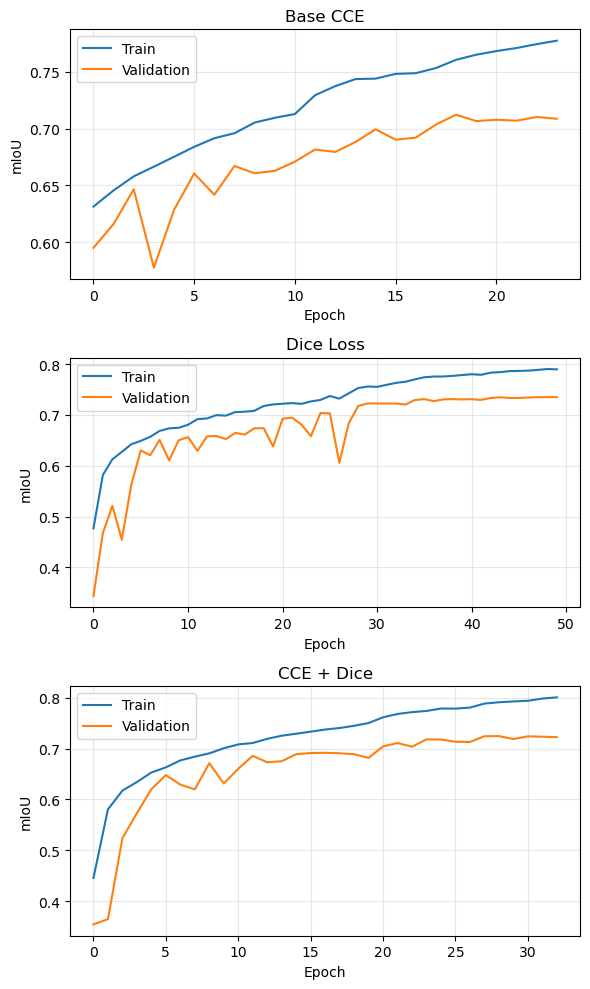

In [7]:
histories = [
    ("Base CCE", history_base),
    ("Dice Loss", history_dice),
    ("CCE + Dice", history_combined)
]

fig, axes = plt.subplots(3,1, figsize=(6,10))
for ax, (title, history) in zip(axes.flat, histories):
    ax.plot(history["mean_iou"], label="Train")
    ax.plot(history["val_mean_iou"], label="Validation")

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mIoU")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(
    "images/training_validation_mIoU.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()